In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *
import time

In [9]:
N = 14
wd = 0.6366896896896898
wm = 1.0
t_max = 3000
tlist = np.linspace(0, t_max, 6000)
reals = 1
dis = 0.0

1 realizations in 8.7 s (8.72905 s per realization)


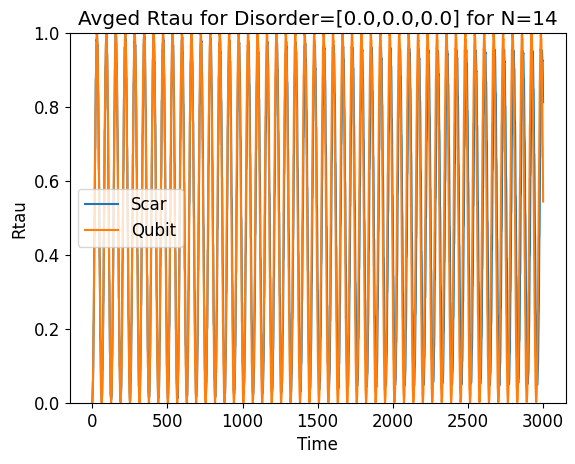

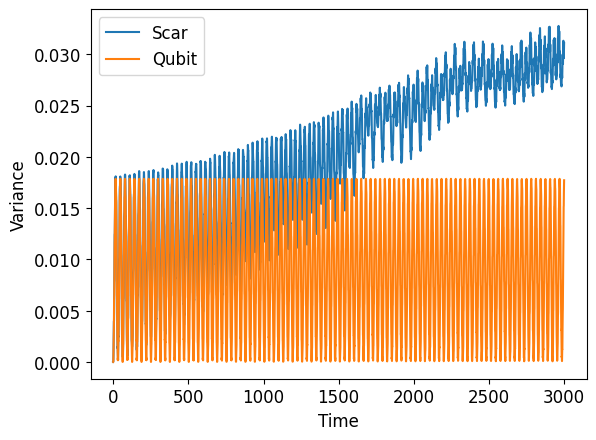

In [ ]:
# VARIANCE CALCULATIONS ARE NOT AVGED OVER REALIZATIONS

dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

t0 = time.perf_counter()
full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    def compute_variance(t, psi):
        return qt.variance(H0, psi)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0, compute_variance])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar
    
    var_scar = psi_t.expect[1] / bandwidth**2

xfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx])

    dE_tot = 0
    bw_tot = 0
    var_qubit = 0

    for qH0, qH1 in zip(qH0_list, qH1_list):
        def compute_variance(t, psi):
            return qt.variance(qH0, psi)
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0, compute_variance])
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

        var_qubit += qpsi_t.expect[1]

    full_qubit += dE_tot / bw_tot
    var_qubit = var_qubit / bw_tot**2

xfull_qubit = full_qubit / reals
elapsed = time.perf_counter() - t0

print(f"{reals} realizations in {elapsed:.1f} s "
      f"({elapsed/reals:.5f} s per realization)")

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.xlabel("Time")
plt.ylabel("Variance")
plt.plot(tlist, var_scar, label="Scar")
plt.plot(tlist, var_qubit, label="Qubit")
plt.legend()
plt.show()

1 realizations in 2.2 s (2.24019 s per realization)


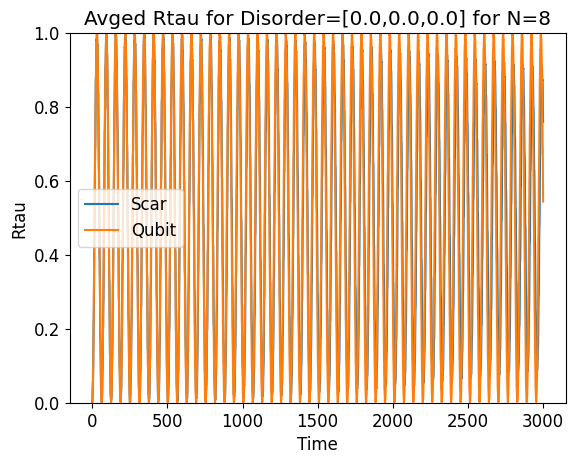

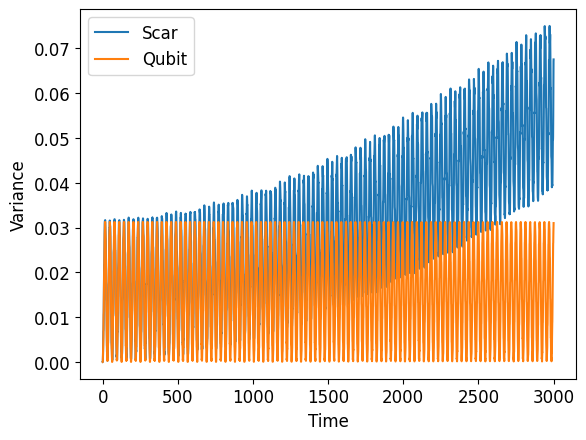

In [17]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

t0 = time.perf_counter()
full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    def compute_variance(t, psi):
        return qt.variance(H0, psi)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0, compute_variance])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar
    
    var_scar = psi_t.expect[1] / bandwidth**2

xfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx])

    dE_tot = 0
    bw_tot = 0
    var_qubit = 0

    for qH0, qH1 in zip(qH0_list, qH1_list):
        def compute_variance(t, psi):
            return qt.variance(qH0, psi)
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0, compute_variance])
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

        var_qubit += qpsi_t.expect[1]

    full_qubit += dE_tot / bw_tot
    var_qubit = var_qubit / bw_tot**2

xfull_qubit = full_qubit / reals
elapsed = time.perf_counter() - t0

print(f"{reals} realizations in {elapsed:.1f} s "
      f"({elapsed/reals:.5f} s per realization)")

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.xlabel("Time")
plt.ylabel("Variance")
plt.plot(tlist, var_scar, label="Scar")
plt.plot(tlist, var_qubit, label="Qubit")
plt.legend()
plt.show()